## Company Analytics, complaint growth rate, clustering, anomaly detection, findings

#### Handling and Response Score

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('/Users/abhaypai/Library/Mobile Documents/com~apple~CloudDocs/Job stuff/Pre 2026/Projects/Portfolio Projects/RBI/Data/complaints_layer2.csv')

In [4]:
response_map = {
    "Closed with monetary relief": 5.0,
    "Closed with non-monetary relief": 4.0,
    "Closed with explanation": 2.5,
    "Closed": 1.5,
    "Untimely response": 0.5
}

In [5]:
df["Response_Score"] = (
    df["Response"]
    .map(response_map)
)

In [8]:
df['Handling_Score'] =np.clip(round(5 - (df['Risk']-df['Response_Score']), 2), 1, 5)

In [9]:
df

,Unnamed: 0,Date,Product,Issue,Narrative,Company,State,ZIP,Date sent,Response,Timely Response,Delay,Issue_Category,Risk,Response_Score,Handling_Score
0,0,2015-06-29,Debt Collection,Communication tactics,I believe that this phone number is for a debt...,AAA Collections,ND,58104,2015-07-01,Closed with explanation,True,1,Debt Collection,2.63,2.5,4.87
1,1,2015-08-25,Lending,Managing the loan or lease,I submitted an application to purchase/finance...,SYNCHRONY FINANCIAL,TN,37087,2015-08-27,Closed with explanation,True,1,Other,1.92,2.5,5.00
2,2,2016-03-25,Debt Collection,False statements or representation,Debt amounts are not accurate when attempting ...,"Duncan Solutions, lnc.",IL,60657,2016-03-26,Closed with explanation,False,1,Debt Collection,3.07,2.5,4.43
3,3,2017-04-09,Credit Reporting,Credit reporting company's investigation,"To whom it may concern, I mailed several lette...","TRANSUNION INTERMEDIATE HOLDINGS, INC.",CT,06614,2017-04-09,Closed with explanation,True,0,Credit Reporting,1.84,2.5,5.00
4,4,2017-08-01,Lending,Trouble during payment process,We have a home mortgage that was purchased by ...,"MONEY SOURCE, INC., THE",TX,75078,2017-08-01,Closed with explanation,True,0,"Billing, Fees & Payments",3.04,2.5,4.46
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
290625,290625,2017-10-10,Credit Reporting,Credit monitoring or identity theft protection...,When the news broke about Equifax I decided to...,"EQUIFAX, INC.",MD,21015,2017-10-10,Closed with explanation,True,0,Fraud & Unauthorized Activity,1.82,2.5,5.00
290626,290626,2017-12-29,Credit Reporting,Incorrect information on your report,cra violation inaccurate information no knowle...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",KS,67217,2017-12-29,Closed with explanation,True,0,Credit Reporting,2.41,2.5,5.00
290627,290627,2016-01-09,Credit Reporting,Incorrect information on credit report,XXXX ( XXXX ) first missed payment XX/XX/XXXX....,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",CA,95828,2016-01-09,Closed with non-monetary relief,True,0,Credit Reporting,3.02,4.0,5.00
290628,290628,2017-03-22,Lending,Can't repay my loan,I have several student loans with SallieMae cu...,SLM CORPORATION,CT,06053,2017-03-22,Closed with explanation,True,0,Loan Servicing & Repayment,3.45,2.5,4.05


In [10]:

def mode_or_first(x):
    m = x.mode()
    return m.iloc[0] if len(m) > 0 else x.iloc[0]

data = df.groupby("Company").agg(
        Complaint_Count=("Company", "size"),

        Avg_Risk=("Risk", "mean"),
        Median_Risk=("Risk", "median"),
        Max_Risk=("Risk", "max"),
        First_Complaint=("Date", "min"),
        Last_Complaint=("Date", "max"),

        Avg_Delay=("Delay", "mean"),

        Avg_Response_Score=("Response_Score", "mean"),
        Avg_Handling_Score=("Handling_Score", "mean"),

        Timely_Response_Pct=(
            "Timely Response",
            lambda x: (x == True).mean() * 100
        ),

        Top_Product=("Product", mode_or_first),
        Top_Issue=("Issue", mode_or_first),
        Top_Category=("Issue_Category", mode_or_first),
        Top_State=("State", mode_or_first),
        Typical_Response=("Response", mode_or_first)
    ).reset_index(inplace=False).sort_values(
        "Complaint_Count",
        ascending=False
    )


In [15]:
data['Last_Complaint'] = pd.to_datetime(data['Last_Complaint'])
data['First_Complaint'] = pd.to_datetime(data['First_Complaint'])

In [16]:
data["Active_Months"] = (
    (
        data["Last_Complaint"].dt.year
        - data["First_Complaint"].dt.year
    ) * 12
    + (
        data["Last_Complaint"].dt.month
        - data["First_Complaint"].dt.month
    )
    + 1
)

In [17]:
data['Avg_Complaints'] = data['Complaint_Count']/data['Active_Months']

In [18]:
data

,Company,Complaint_Count,Avg_Risk,Median_Risk,Max_Risk,First_Complaint,Last_Complaint,Avg_Delay,Avg_Response_Score,Avg_Handling_Score,Timely_Response_Pct,Top_Product,Top_Issue,Top_Category,Top_State,Typical_Response,Active_Months,Avg_Complaints
1152,"EQUIFAX, INC.",29126,2.713453,2.73,4.55,2015-06-16,2018-06-16,0.509030,2.647451,4.725397,97.449015,Credit Reporting,Incorrect information on your report,Credit Reporting,CA,Closed with explanation,37,787.189189
1240,Experian Information Solutions Inc.,22264,2.520730,2.51,4.73,2015-06-16,2018-06-16,0.470850,3.055875,4.888152,99.995508,Credit Reporting,Incorrect information on your report,Credit Reporting,CA,Closed with explanation,37,601.729730
3293,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",22012,2.543001,2.54,4.75,2015-06-16,2018-06-16,0.600445,2.740823,4.839256,99.813738,Credit Reporting,Incorrect information on your report,Credit Reporting,CA,Closed with explanation,37,594.918919
3584,WELLS FARGO & COMPANY,11074,2.550923,2.53,4.72,2015-06-16,2018-06-16,0.585967,2.921528,4.791184,90.030703,Lending,"Loan modification,collection,foreclosure",Loan Servicing & Repayment,CA,Closed with explanation,37,299.297297
613,"CITIBANK, N.A.",10453,2.321355,2.31,5.00,2015-06-16,2018-06-16,0.771932,3.274658,4.885839,99.866067,Cards,"Account opening, closing, or management",Other,CA,Closed with explanation,37,282.513514
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1964,Layfayette Funding,1,2.710000,2.71,2.71,2018-03-30,2018-03-30,44.000000,2.500000,4.790000,100.000000,Lending,Getting a line of credit,Other,NaN,Closed with explanation,1,1.000000
1963,"Lawyers Title of Cincinnati, Inc.",1,3.780000,3.78,3.78,2018-04-18,2018-04-18,35.000000,2.500000,3.720000,100.000000,Lending,Trouble during payment process,"Billing, Fees & Payments",KY,Closed with explanation,1,1.000000
1962,"Lawrence A. Patish, P.C.",1,1.890000,1.89,1.89,2017-03-29,2017-03-29,151.000000,2.500000,5.000000,100.000000,Debt Collection,Disclosure verification of debt,Debt Collection,MA,Closed with explanation,1,1.000000
1961,Law Offices of Vincent J. Buzek,1,2.380000,2.38,2.38,2016-03-22,2016-03-22,0.000000,2.500000,5.000000,0.000000,Debt Collection,Disclosure verification of debt,Debt Collection,CO,Closed with explanation,1,1.000000


In [19]:
data = data.drop(columns=['First_Complaint', 'Last_Complaint'])

In [105]:
data[data['Complaint_Count']>100].sort_values(by='Avg_Risk', ascending=False)

,Company,Complaint_Count,Avg_Risk,Median_Risk,Max_Risk,Avg_Delay,Avg_Response_Score,Avg_Handling_Score,Timely_Response_Pct,Top_Product,Top_Issue,Top_Category,Top_State,Typical_Response,Active_Months,Avg_Complaints
2905,"Reverse Mortgage Solutions, Inc.",104,2.890000,2.875,3.70,3.586538,2.384615,4.478846,96.153846,Lending,"Loan modification,collection,foreclosure",Loan Servicing & Repayment,CA,Closed with explanation,37,2.810811
3087,Selene Finance LP,308,2.882955,2.895,3.69,1.110390,2.493506,4.591558,99.025974,Lending,"Loan modification,collection,foreclosure",Loan Servicing & Repayment,FL,Closed with explanation,37,8.324324
2807,RUSHMORE LOAN MANAGEMENT SERVICES LLC,367,2.874332,2.890,3.68,1.070845,2.500000,4.597820,99.727520,Lending,"Loan modification,collection,foreclosure",Loan Servicing & Repayment,CA,Closed with explanation,37,9.918919
2305,NATIONSTAR MORTGAGE LLC,3615,2.870136,2.880,3.88,0.868603,2.481881,4.578949,99.889350,Lending,"Loan servicing, payments, escrow account",Loan Servicing & Repayment,CA,Closed with explanation,37,97.702703
3283,TMX Finance LLC,154,2.867857,2.890,3.53,2.110390,2.493506,4.609740,98.701299,Lending,Charged fees or interest I didn't expect,Loan Servicing & Repayment,GA,Closed with explanation,37,4.162162
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2616,"Paypal Holdings, Inc",1781,2.353734,2.340,3.36,2.108366,3.333240,4.971589,99.831555,Payment & Money Services,Fraud or scam,Other,CA,Closed with explanation,37,48.135135
2405,Netspend Corporation,426,2.343380,2.330,3.20,4.112676,2.563380,4.945540,100.000000,Cards,Unauthorized transactions/trans. issues,Other,CA,Closed with explanation,37,11.513514
414,BARCLAYS BANK DELAWARE,1837,2.342852,2.330,3.43,0.970604,3.175286,4.953076,99.945563,Cards,Billing disputes,Other,CA,Closed with explanation,37,49.648649
494,Blackhawk Network Holdings Inc.,141,2.342553,2.330,3.05,8.517730,3.521277,4.985106,100.000000,Cards,"Managing, opening, or closing account",Fraud & Unauthorized Activity,CA,Closed with explanation,36,3.916667


## Calculating complaint growth rate

In [20]:
df['Year'] = pd.to_datetime(df['Date']).dt.year

In [21]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

yearly = (
    df.groupby(["Company", "Year"])
      .size()
      .reset_index(name="Complaint_Count")
)

growth_metrics = []

for company, group in yearly.groupby("Company"):

    group = group.sort_values("Year")

    X = group["Year"].values.reshape(-1, 1)
    y = group["Complaint_Count"].values

    model = LinearRegression()
    model.fit(X, y)

    growth_metrics.append({
        "Company": company,
        "Complaint_Growth_Slope": round(model.coef_[0],2),
        "Mean_Complaints": y.mean(),
    })

growth = pd.DataFrame(growth_metrics)

In [22]:
growth['Complaint_Growth_Rate'] = growth['Complaint_Growth_Slope']/growth['Mean_Complaints']*100

In [24]:
growth.sort_values(by='Complaint_Growth_Rate', ascending=False)

,Company,Complaint_Growth_Slope,Mean_Complaints,Complaint_Growth_Rate
1241,Express Aviation,21.0,12.5,168.000000
1386,"First Recovery Solutions, Inc.",30.0,18.0,166.666667
2763,"RAS LaVrar, LLC",7.0,4.5,155.555556
194,"Advantage One Credit, LLC",7.0,4.5,155.555556
2476,Oakridge Direct Solutions Inc.,7.0,4.5,155.555556
...,...,...,...,...
176,Activehours,-11.0,7.5,-146.666667
297,"Andreu, Palma & Andreu, PL",-6.0,4.0,-150.000000
1689,"IMC Capital, LLC",-14.0,9.0,-155.555556
3388,"Timothy C. Runyan, P.C.",-7.0,4.5,-155.555556


In [25]:
data = data.merge(
    growth[
        [
            "Company",
            "Complaint_Growth_Rate"
        ]
    ],
    on="Company",
    how="left"
)

## K Means

In [26]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

In [27]:
X = data.drop(columns=['Company', 'Top_Product', 'Top_Issue', 'Top_Category', 'Top_State', 'Typical_Response', 'Median_Risk', 'Complaint_Growth_Rate']).reset_index().drop(columns='index')
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

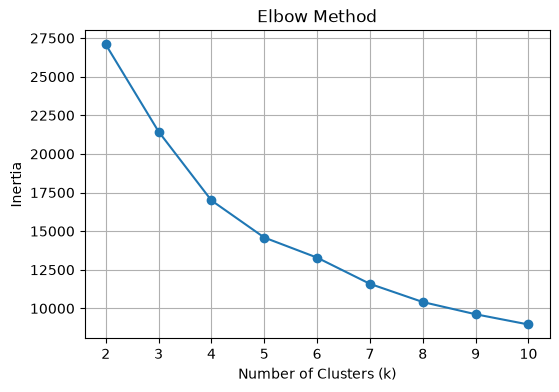

In [28]:
inertia = []

for k in range(2, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(2,11), inertia, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid(True)

In [29]:
# -----------------------------
# Silhouette Scores
# -----------------------------
scores = {}

for k in range(2,11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores[k] = score

print(scores)
best_k = max(scores, key=scores.get)
print(f"Best k: {best_k}")

# -----------------------------
# Final Model
# -----------------------------
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=20
)

data['Cluster'] = kmeans.fit_predict(X_scaled)
X['Cluster'] = kmeans.fit_predict(X_scaled)

{2: 0.44233862027807, 3: 0.45393862886224495, 4: 0.30487832111355334, 5: 0.3157816969572703, 6: 0.3133153556619092, 7: 0.3191492762008948, 8: 0.32825758482874406, 9: 0.33139693043696633, 10: 0.2354870566983076}
Best k: 3


In [200]:
data[data['Cluster']==2]

,Company,Complaint_Count,Avg_Risk,Median_Risk,Max_Risk,Avg_Delay,Avg_Response_Score,Avg_Handling_Score,Timely_Response_Pct,Top_Product,Top_Issue,Top_Category,Top_State,Typical_Response,Active_Months,Avg_Complaints,Cluster,Complaint_Growth_Rate
0,"EQUIFAX, INC.",29126,2.680814,2.68,3.75,0.509030,2.647451,4.778798,97.449015,Credit Reporting,Incorrect information on your report,Credit Reporting,CA,Closed with explanation,37,787.189189,2,25.695255
1,Experian Information Solutions Inc.,22264,2.540035,2.53,3.69,0.470850,3.055875,4.912832,99.995508,Credit Reporting,Incorrect information on your report,Credit Reporting,CA,Closed with explanation,37,601.729730,2,29.306504
2,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",22012,2.514232,2.51,3.69,0.600445,2.740823,4.896843,99.813738,Credit Reporting,Incorrect information on your report,Credit Reporting,CA,Closed with explanation,37,594.918919,2,27.461385
3,WELLS FARGO & COMPANY,11074,2.609241,2.59,3.93,0.585967,2.921528,4.821356,90.030703,Lending,"Loan modification,collection,foreclosure",Loan Servicing & Repayment,CA,Closed with explanation,37,299.297297,2,-0.158931
4,"CITIBANK, N.A.",10453,2.384104,2.35,3.72,0.771932,3.274658,4.933780,99.866067,Cards,"Account opening, closing, or management",Other,CA,Closed with explanation,37,282.513514,2,1.281929
5,"BANK OF AMERICA, NATIONAL ASSOCIATION",10355,2.533708,2.50,3.76,0.662772,3.185659,4.858638,99.903428,Deposit Accounts,"Loan modification,collection,foreclosure",Other,CA,Closed with explanation,37,279.864865,2,-1.417673
6,"Navient Solutions, LLC.",10342,2.673608,2.68,3.73,1.071456,2.563721,4.778312,99.980661,Lending,Dealing with my lender or servicer,Loan Servicing & Repayment,CA,Closed with explanation,37,279.513514,2,30.299749
7,JPMORGAN CHASE & CO.,9967,2.457575,2.42,3.89,0.556336,2.962025,4.891181,99.969901,Cards,Managing an account,Other,CA,Closed with explanation,37,269.378378,2,3.904886
8,CAPITAL ONE FINANCIAL CORPORATION,7455,2.447418,2.43,3.63,0.644668,2.789604,4.909027,99.973172,Cards,Incorrect information on your report,Other,CA,Closed with explanation,37,201.486486,2,21.467471


In [201]:
data.to_csv('/Users/abhaypai/Library/Mobile Documents/com~apple~CloudDocs/Job stuff/Pre 2026/Projects/Portfolio Projects/RBI/Data/institutions.csv')

In [202]:
data['Cluster'].value_counts()

Cluster
0    1818
3    1540
1     332
2       9
Name: count, dtype: int64

In [30]:
X.groupby("Cluster").mean().round(2)

,Complaint_Count,Avg_Risk,Max_Risk,Avg_Delay,Avg_Response_Score,Avg_Handling_Score,Timely_Response_Pct,Active_Months,Avg_Complaints
Cluster,,,,,,,,,
0,2.33,2.59,2.74,27.51,2.77,4.79,79.45,5.86,0.78
1,14783.11,2.52,4.70,0.65,2.90,4.81,98.55,37.00,399.54
2,76.55,2.80,3.58,6.08,2.63,4.59,88.99,27.62,2.26
3,4.25,2.75,3.02,15.05,0.86,3.09,6.14,10.33,0.74


## Outlier detection

In [31]:
from sklearn.ensemble import IsolationForest

features = data.select_dtypes(include="number")

iso = IsolationForest(
    contamination=0.03,
    random_state=42
)

data["Anomaly"] = iso.fit_predict(features)

anomalies = data[data["Anomaly"] == -1]

In [32]:
anomalies.to_csv('/Users/abhaypai/Library/Mobile Documents/com~apple~CloudDocs/Job stuff/Pre 2026/Projects/Portfolio Projects/RBI/Data/institution_anomalies.csv')

In [33]:
anomalies['Cluster'].value_counts()

Cluster
3    72
0    16
2    14
1     9
Name: count, dtype: int64

## Findings

In [34]:
#Total of X firms account for Y% of total complaints
data[data['Cluster']==2]['Complaint_Count'].sum() / data['Complaint_Count'].sum()

np.float64(0.5262361077658879)

In [35]:
threshold = data["Avg_Risk"].quantile(0.95)

high_risk = data[data["Avg_Risk"] >= threshold]

print(len(high_risk))

186


In [36]:
# High growth rate with subpar handling
growth_risk = data[
    (data["Complaint_Growth_Rate"] > 20)
    &
    (data["Avg_Handling_Score"] < 3.5)
]

growth_risk.sort_values(
    "Complaint_Growth_Rate",
    ascending=False
)

,Company,Complaint_Count,Avg_Risk,Median_Risk,Max_Risk,Avg_Delay,Avg_Response_Score,Avg_Handling_Score,Timely_Response_Pct,Top_Product,Top_Issue,Top_Category,Top_State,Typical_Response,Active_Months,Avg_Complaints,Complaint_Growth_Rate,Cluster,Anomaly
515,"First Recovery Solutions, Inc.",36,2.565278,2.575,3.48,0.638889,0.500000,2.934722,0.000000,Debt Collection,Cont'd attempts collect debt not owed,Debt Collection,MD,Untimely response,6,6.000000,166.666667,3,-1
1243,Oakridge Direct Solutions Inc.,9,2.370000,2.390,2.66,19.222222,0.722222,3.352222,11.111111,Debt Collection,Communication tactics,Debt Collection,CA,Untimely response,18,0.500000,155.555556,3,-1
1306,"Advantage One Credit, LLC",9,2.592222,2.460,3.80,9.222222,0.500000,2.907778,0.000000,Lending,Can't contact lender or servicer,Customer Service & Disclosures,FL,Untimely response,14,0.642857,155.555556,3,-1
1783,HOME FINANCE OF AMERICA,5,2.986000,3.030,3.63,0.000000,0.500000,2.514000,0.000000,Lending,Closing on a mortgage,Debt Collection,CA,Untimely response,9,0.555556,120.000000,3,-1
1879,"The Schreiber Law Firm, PLLC",4,2.990000,2.935,3.50,0.000000,0.500000,2.510000,0.000000,Debt Collection,Attempts to collect debt not owed,Debt Collection,CO,Untimely response,14,0.285714,100.000000,3,-1
1979,"Credit Bureau Financial Services, Inc.",4,2.605000,2.580,3.39,0.250000,0.500000,2.895000,0.000000,Credit Reporting,Unable to get your credit report or credit score,Credit Reporting,MA,Untimely response,13,0.307692,100.000000,3,1
2197,"North American Asset Services, LLC",3,2.440000,2.090,3.60,4.666667,0.500000,3.060000,0.000000,Credit Reporting,Improper use of your report,Credit Reporting,FL,Untimely response,7,0.428571,66.666667,3,1
2210,Round Two Recovery,3,2.440000,2.490,2.51,0.666667,0.500000,3.060000,0.000000,Debt Collection,Cont'd attempts collect debt not owed,Debt Collection,MD,Untimely response,7,0.428571,66.666667,3,1
2015,"Ignite Revenue, Inc.",3,2.476667,2.840,3.08,0.333333,0.500000,3.023333,0.000000,Cards,Attempts to collect debt not owed,Debt Collection,CA,Untimely response,10,0.300000,66.666667,3,1
2136,Cornerstone Mitigation,3,2.360000,2.310,2.78,4.333333,0.500000,3.140000,0.000000,Lending,Charged fees or interest I didn't expect,"Billing, Fees & Payments",FL,Untimely response,9,0.333333,66.666667,3,1


In [217]:
numeric = data.select_dtypes(include="number")

for target in numeric.columns:

    corr = (
        numeric.corr()[target]
        .drop(target)
        .sort_values(key=abs, ascending=False)
        .head(5)
    )

    print("\n", target)
    print(corr)


 Complaint_Count
Avg_Complaints         0.999312
Anomaly               -0.317443
Max_Risk               0.164364
Active_Months          0.118469
Timely_Response_Pct    0.050937
Name: Complaint_Count, dtype: float64

 Avg_Risk
Median_Risk           0.977459
Max_Risk              0.540546
Avg_Handling_Score   -0.269064
Active_Months        -0.137530
Avg_Delay             0.051891
Name: Avg_Risk, dtype: float64

 Median_Risk
Avg_Risk              0.977459
Max_Risk              0.508046
Avg_Handling_Score   -0.265811
Active_Months        -0.132461
Avg_Delay             0.046424
Name: Median_Risk, dtype: float64

 Max_Risk
Active_Months          0.598678
Cluster               -0.597919
Avg_Risk               0.540546
Median_Risk            0.508046
Timely_Response_Pct    0.180404
Name: Max_Risk, dtype: float64

 Avg_Delay
Active_Months   -0.270163
Cluster          0.245041
Max_Risk        -0.166390
Anomaly         -0.088715
Avg_Risk         0.051891
Name: Avg_Delay, dtype: float64

 Avg_Re

In [38]:
data = round(data, 2)

In [41]:
data.to_csv('/Users/abhaypai/Library/Mobile Documents/com~apple~CloudDocs/Job stuff/Pre 2026/Projects/Portfolio Projects/RBI/Data/institutions.csv')

In [42]:
data

,Company,Complaint_Count,Avg_Risk,Median_Risk,Max_Risk,Avg_Delay,Avg_Response_Score,Avg_Handling_Score,Timely_Response_Pct,Top_Product,Top_Issue,Top_Category,Top_State,Typical_Response,Active_Months,Avg_Complaints,Complaint_Growth_Rate,Cluster,Anomaly
0,"EQUIFAX, INC.",29126,2.71,2.73,4.55,0.51,2.65,4.73,97.45,Credit Reporting,Incorrect information on your report,Credit Reporting,CA,Closed with explanation,37,787.19,25.70,1,-1
1,Experian Information Solutions Inc.,22264,2.52,2.51,4.73,0.47,3.06,4.89,100.00,Credit Reporting,Incorrect information on your report,Credit Reporting,CA,Closed with explanation,37,601.73,29.31,1,-1
2,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",22012,2.54,2.54,4.75,0.60,2.74,4.84,99.81,Credit Reporting,Incorrect information on your report,Credit Reporting,CA,Closed with explanation,37,594.92,27.46,1,-1
3,WELLS FARGO & COMPANY,11074,2.55,2.53,4.72,0.59,2.92,4.79,90.03,Lending,"Loan modification,collection,foreclosure",Loan Servicing & Repayment,CA,Closed with explanation,37,299.30,-0.16,1,-1
4,"CITIBANK, N.A.",10453,2.32,2.31,5.00,0.77,3.27,4.89,99.87,Cards,"Account opening, closing, or management",Other,CA,Closed with explanation,37,282.51,1.28,1,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3694,Layfayette Funding,1,2.71,2.71,2.71,44.00,2.50,4.79,100.00,Lending,Getting a line of credit,Other,NaN,Closed with explanation,1,1.00,0.00,0,1
3695,"Lawyers Title of Cincinnati, Inc.",1,3.78,3.78,3.78,35.00,2.50,3.72,100.00,Lending,Trouble during payment process,"Billing, Fees & Payments",KY,Closed with explanation,1,1.00,0.00,2,1
3696,"Lawrence A. Patish, P.C.",1,1.89,1.89,1.89,151.00,2.50,5.00,100.00,Debt Collection,Disclosure verification of debt,Debt Collection,MA,Closed with explanation,1,1.00,0.00,0,1
3697,Law Offices of Vincent J. Buzek,1,2.38,2.38,2.38,0.00,2.50,5.00,0.00,Debt Collection,Disclosure verification of debt,Debt Collection,CO,Closed with explanation,1,1.00,0.00,0,1


In [3]:
import plotly.express as px

In [15]:
fig = px.histogram(
    df['Risk'],
    x='Risk',
    nbins=100,
)

In [37]:
fig.add_vline(x=3,
              line_color='red',
              annotation_text='Risk: ')

fig.update_layout(
    plot_bgcolor='white',
    title={
        'text': "<b>Risk distribution</b><br><span style='color:#6A7383; font-size:12px;'>Overall breakdown of risk scores across 290k records</span>",
        'y': 0.93,
        'x': 0.05,
        'xanchor': 'left',
        'yanchor': 'top',
        'font': dict(family="Inter, Segoe UI, Arial", size=18, color='#1A1F36') # Stripe uses clean sans-serif
    },
    bargap=0.5, # The magic parameter: adds a subtle modern gap between bars
    
    # Clean up X-Axis
    xaxis=dict(
        title=None,
        showgrid=False, # Remove vertical gridlines entirely
        showticklabels=True,
        tickvals=[1,2.5,5],
        tickfont=dict(family="Arial", size=11, color='#4F566B'),
        linecolor='#E3E8EE', # Subtle bottom axis border
    ),
    
    # Clean up Y-Axis
    yaxis=dict(
        title=None,
        showgrid=False,
        showticklabels=False,
        gridcolor='#F7F8F9', # Ultra-faint horizontal gridlines
        zeroline=False
    ),
    
    margin=dict(l=60, r=40, t=80, b=60), # Generous padding
    width=900,
    height=450
)